# (27) ICLR code + mlp decoder

**Motivation**: host = ```chewie```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from main.config_defaults import default_configs
from figures.convergence import plot_convergence
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Poisson + MNIST

**Task:** reproduce gold standard

Dataset: ```MNIST```

### Get configs

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'ngd|mlp')

t_train = 10

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 4/8 * t_train

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

120000

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  567.1 K   |
|     ———     |    ———     |
|    layer    |  567.1 K   |
+-------------+------------+

poisson_MNIST_t-10_b-5_k-128_<ngd|mlp>
b200-ep400-lr(0.002)_temp(0.05:0.5)_gr(50)_(2025_05_28,17:53)

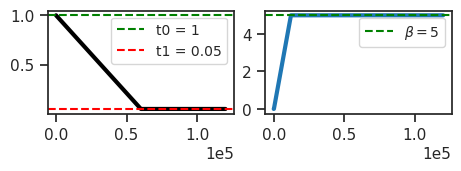

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  567.1 K   |
|     ———      |    ———     |
|     dec      |  566.8 K   |
|    u_init    |    128     |
+--------------+------------+

In [7]:
model.layer.n_exp

tensor([50, 50, 50, 50, 50, 50, 50, 50, 50, 50], device='cuda:1',
       dtype=torch.int32)

In [8]:
model.cfg.track_stats

True

In [9]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'prior_log_dist': 'uniform', 'clamp_prior': -2, 't_train': 10, 'kl_beta': 5.0, 'n_latents': 128, 'enc_type': 
'ngd', 'dec_type': 'mlp', 'recon_mode': 'mse', 'dataset': 'MNIST', 'dataset_name': 'MNIST', 'feeder': 'stationary',
'feeder_cfg': {}, 'input_sz': (1, 28, 28), 'shape': (-1, 1, 28, 28), 'init_dist': 'normal', 'init_scale': 0.001, 
'clamp_vals': {'u': (7.0,), 'du': (5.0,), 'dec': 3.45}, 'stochastic': True, 'fit_dec_var': False, 'fit_prior': 
True, 'seed': 0, 'track_stats': True, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_MNIST_t-10_b-5_k-128_<ngd|mlp>', 
'mods_dir': '/home/hadi/Projects/PoissonVAE/models/poisson_MNIST_t-10_b-5_k-128_<ngd|mlp>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.002, 'epochs': 400, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0003, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 398.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 50,
'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'method': 'mc', 'kl_beta_min': 0.0001, 'kl_const_portion': 
0.001, 'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 
'temp_stop': 0.05}

In [10]:
print(tr.model.layer.dec)

Sequential(
  (0): Linear(in_features=128, out_features=256, bias=True)
  (1): SiLU(inplace=True)
  (2): Linear(in_features=256, out_features=512, bias=True)
  (3): SiLU(inplace=True)
  (4): Linear(in_features=512, out_features=784, bias=True)
)

In [11]:
print(tr.model.cfg.clamp_vals)

{'u': (7.0,), 'du': (5.0,), 'dec': 3.45}

### Fit model

In [12]:
tr.train('Phase8:clamps_u=7.0_du=5.0+MLP')

Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

epoch # 400, avg loss: 25.748: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [1:09:12<00:00, 10.38s/it]


In [13]:
print(tr.model.layer.n_exp)

tensor([10, 16, 23, 28, 31, 32, 33, 34, 35, 36], device='cuda:1',
       dtype=torch.int32)

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.31s/it]


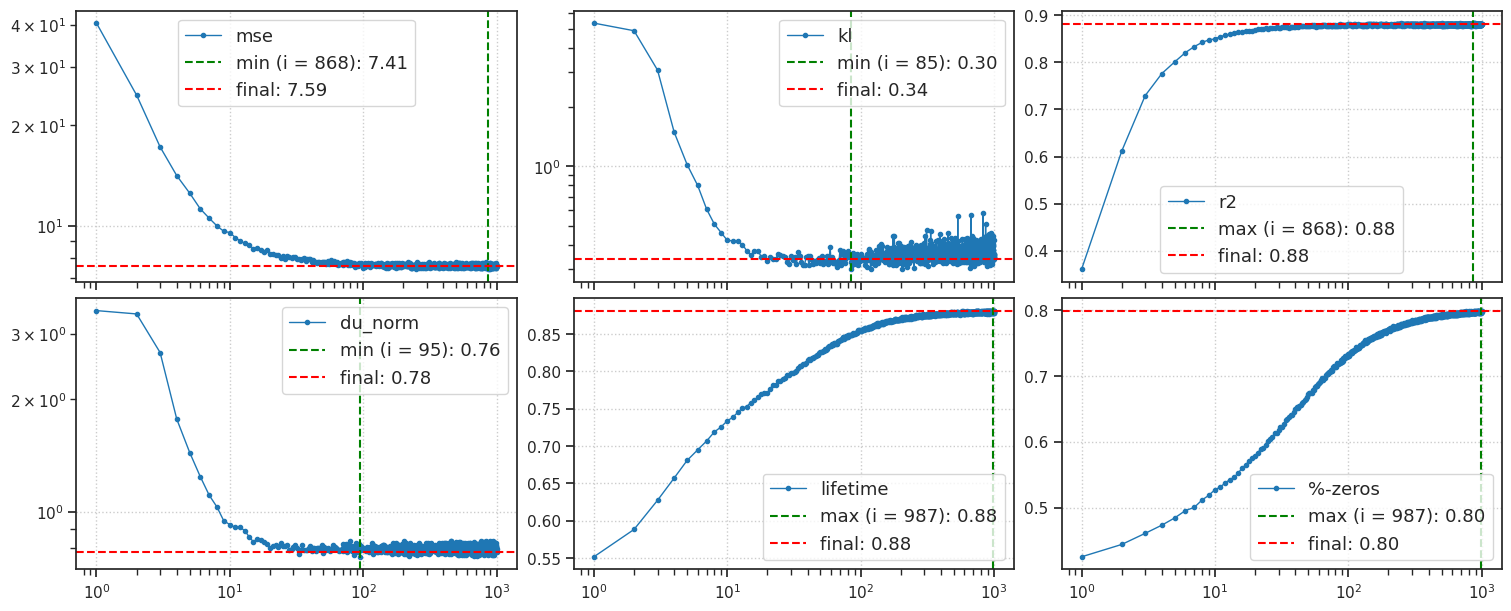

CPU times: user 6.17 s, sys: 88.1 ms, total: 6.26 s
Wall time: 6.25 s


In [14]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis(dl='vld', **kws)
_ = plot_convergence(results, color='C0')

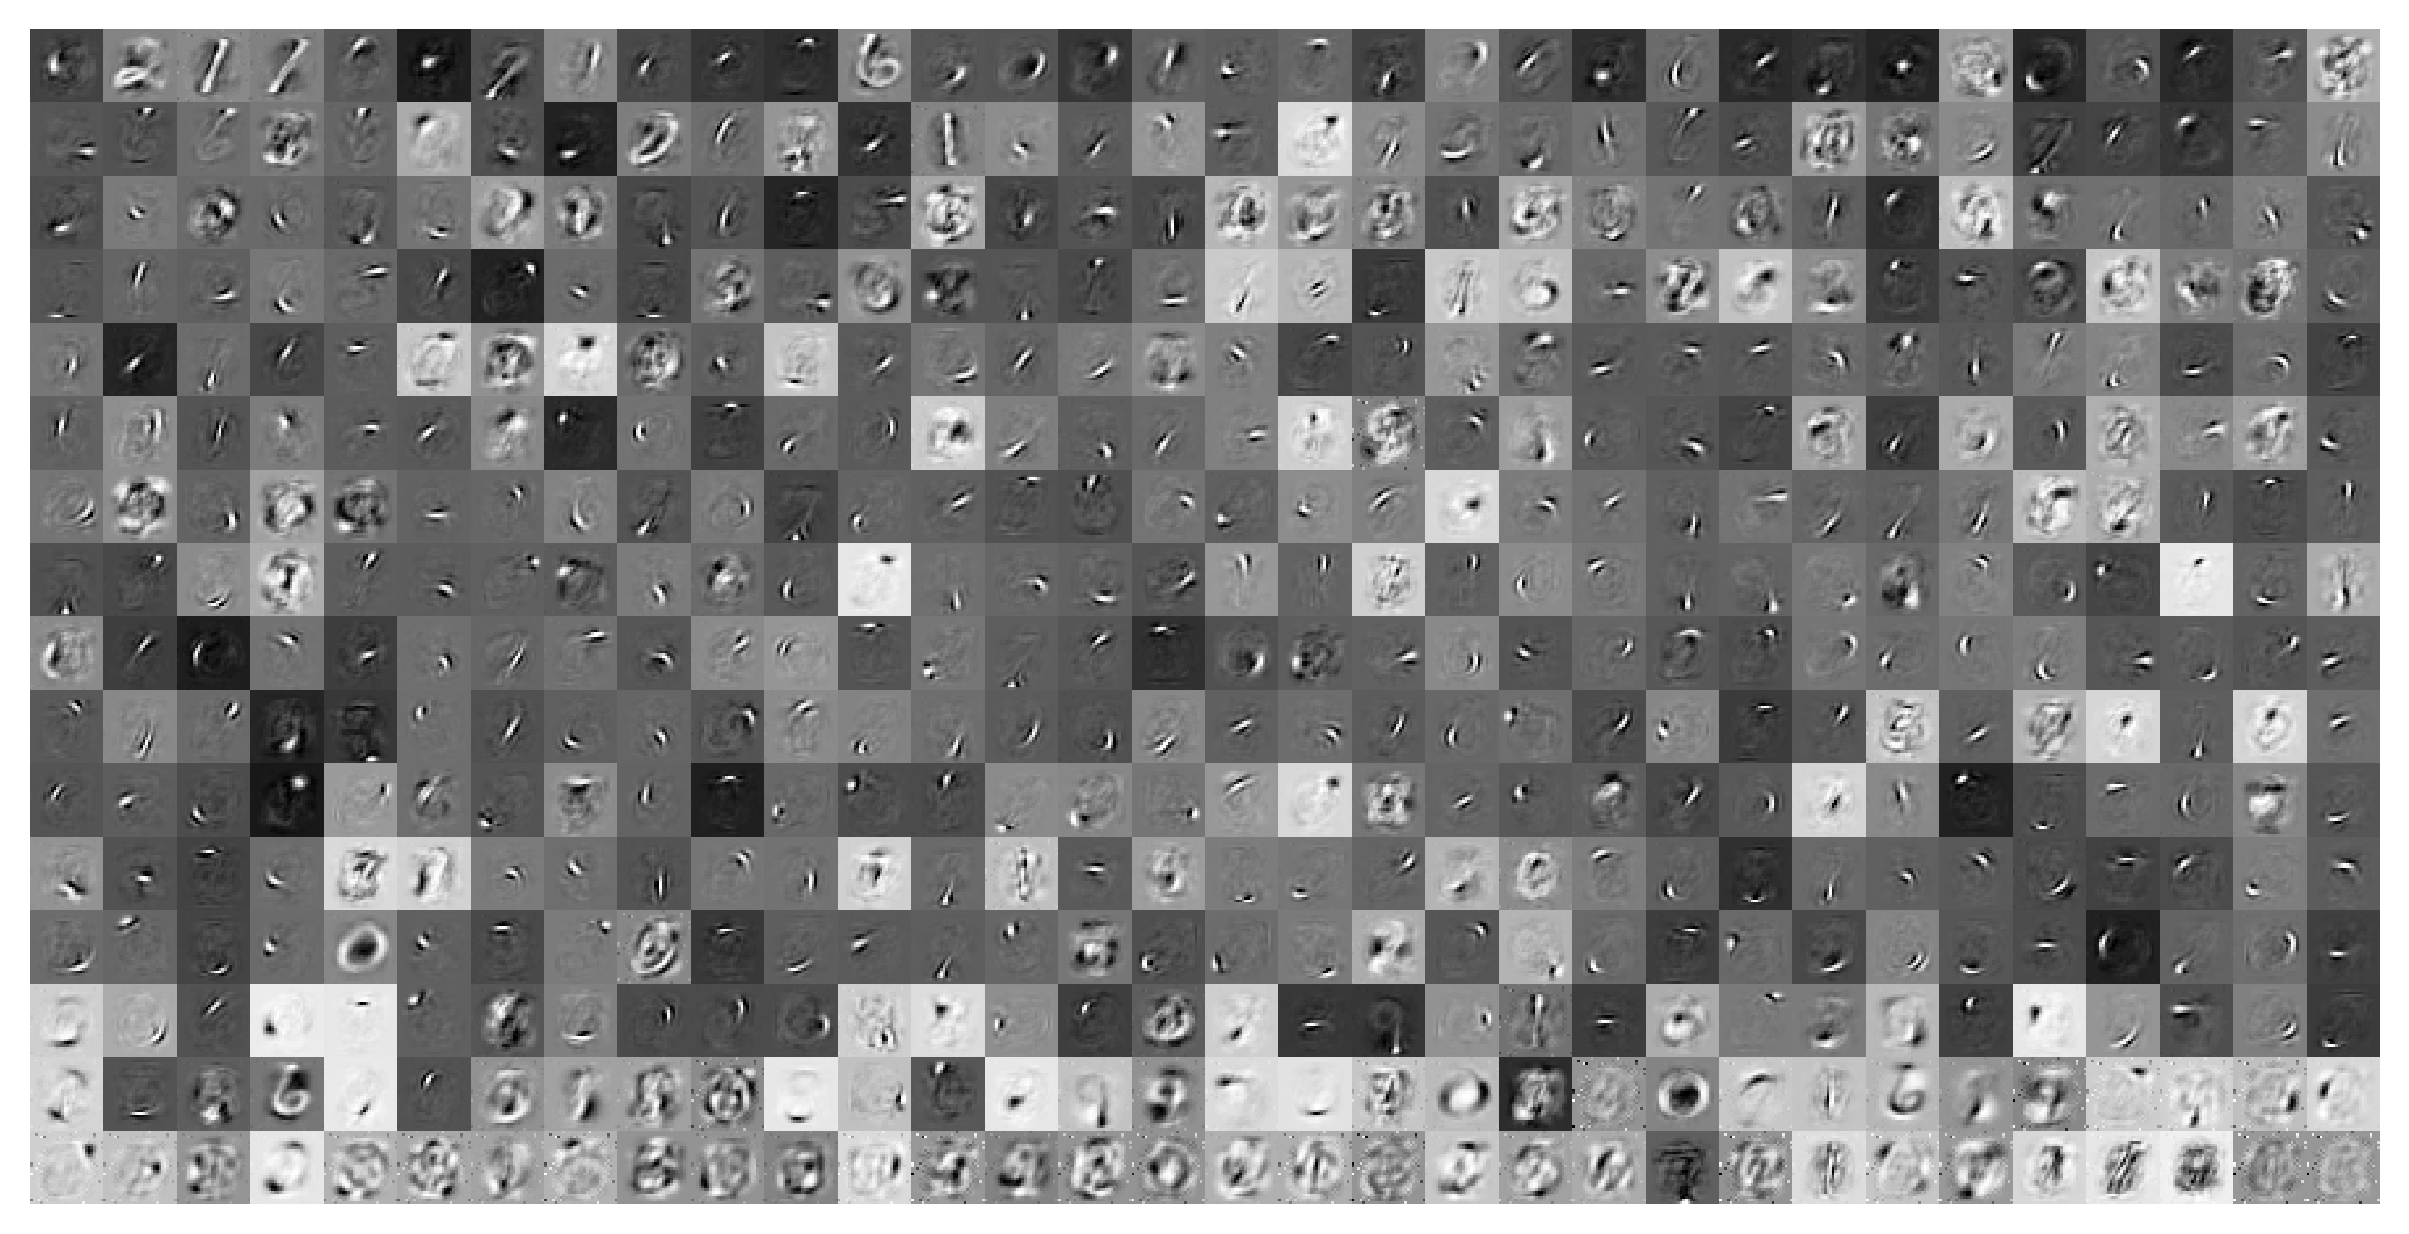

In [15]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))
tr.model.show(order=np.argsort(norms), dpi=300, pad=0);

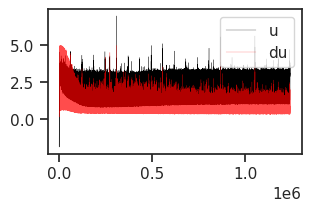

In [16]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

In [17]:
max(tr.model.stats['du_max']), np.quantile(tr.model.stats['du_max'], 0.999)

(5.0, 4.798670323371885)

In [18]:
max(tr.model.stats['u_max']), np.quantile(tr.model.stats['u_max'], 0.999)

(6.993002891540527, 3.4851053054332715)

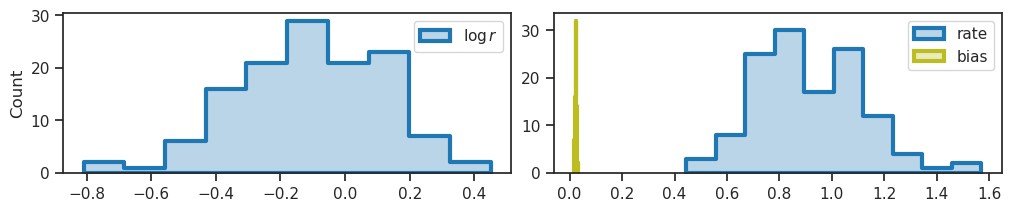

In [19]:
log_rate = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.log_bias.exp().squeeze())

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [20]:
dead = log_rate < -1
dead.sum(), (~dead).sum(), dead.sum() / len(dead)

(0, 128, 0.0)

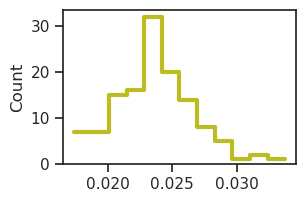

In [21]:
histplot(bias, color='C8', lw=3)
plt.show()

In [22]:
(bias > 0).mean()

1.0

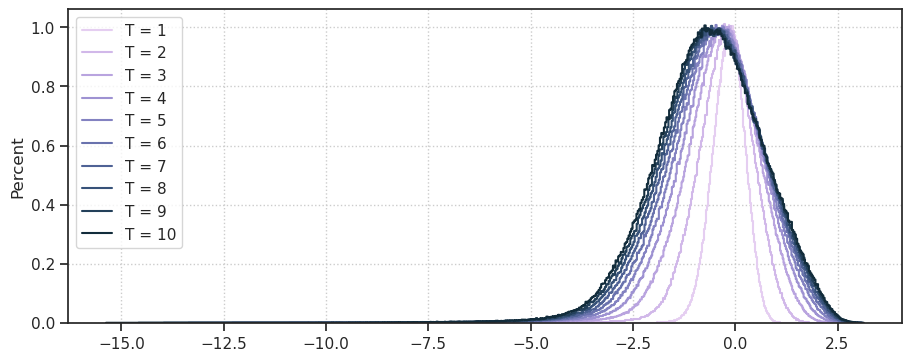

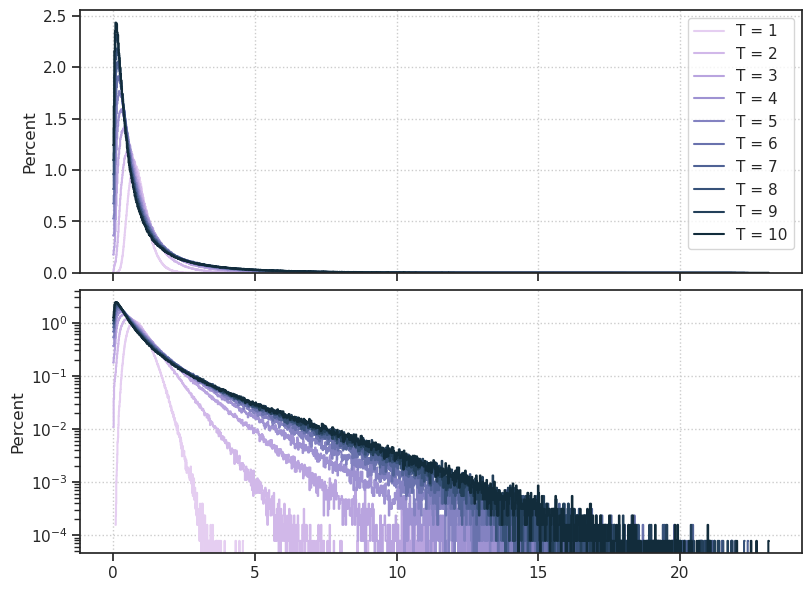

In [23]:
mult = 1

results = tr.xtract_ftr(
    t_total=tr.model.cfg.t_train * mult,
    save_freq=mult,
    n_data_batches=10,
    data_batch_sz=2000,
    verbose=False,
)


fig, ax = create_figure(1, 1, (9, 3.5))
pal = get_cubehelix_palette(len(results['times']), start=2.5)

for i, t in enumerate(results['times']):
    sns.histplot(
        results['state_0'][:, i].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
ax.legend(loc='upper left')
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (8, 5.8), sharex='col')
for i, t in enumerate(results['times']):
    for ax in axes.flat:
        sns.histplot(
            np.exp(results['state_0'][:, i].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[0].legend()
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

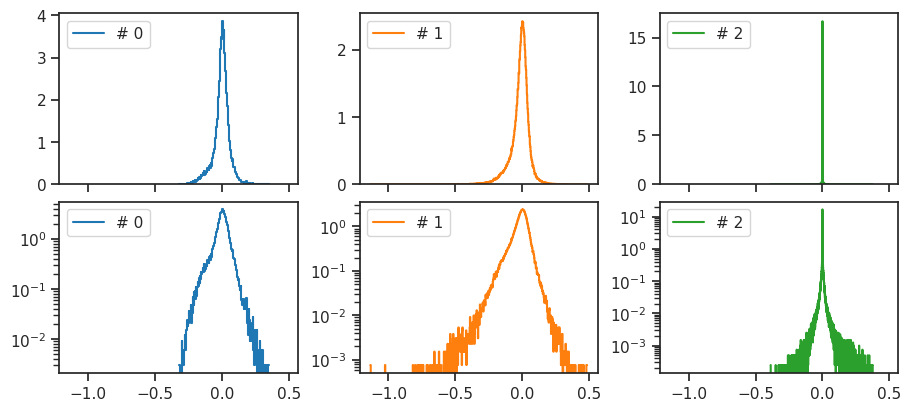

In [24]:
linear_layers = list(filter(
    lambda m: hasattr(m, 'weight'),
    tr.model.layer.dec,
))

fig, axes = create_figure(2, len(linear_layers), sharex='all')
for i, m in enumerate(linear_layers):
    if hasattr(m, 'weight'):
        w = m.weight.data
    for ax in axes[:, i]:
        sns.histplot(
            tonp(w.ravel()), 
            stat='percent',
            element='step',
            fill=False,
            label=f"# {i}",
            color=f"C{i}",
            ax=ax,
        )
    axes[0, i].set(yscale='linear', ylabel='')
    axes[1, i].set(yscale='log', ylabel='')
add_legend(axes)
plt.show()

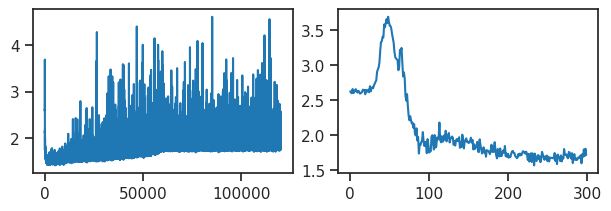

In [25]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300])
plt.show()

In [26]:
(grad > 100).sum()

1

100%|█████████████████████████████████| 50/50 [01:54<00:00,  2.28s/it]


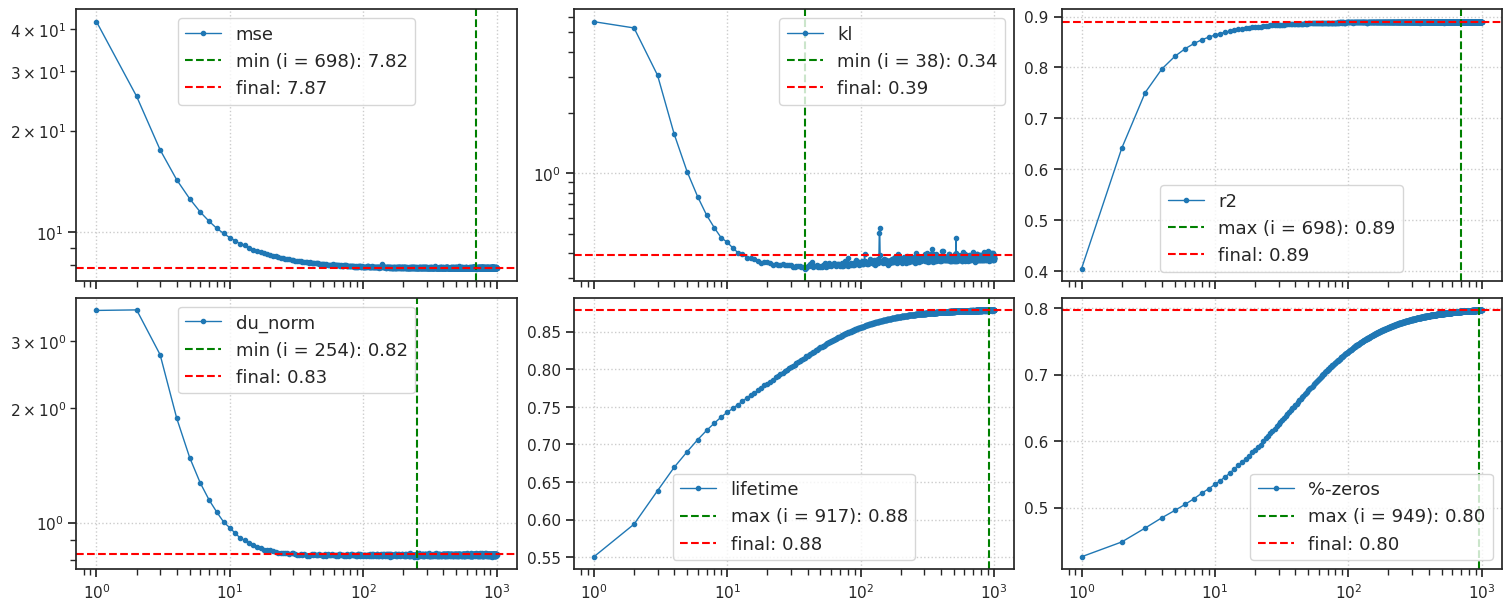

CPU times: user 2min 1s, sys: 918 ms, total: 2min 2s
Wall time: 2min 2s


In [27]:
%%time

kws = dict(
    t_total=1000,
    compute_sprs=True,
)
results = tr.analysis(dl='vld', **kws)
_ = plot_convergence(results, color='C0')